# Importing the libraries

In [45]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from networkx.algorithms.community import modularity
from typing import List, Optional, Tuple, Dict, Set

In [46]:
# Function to divide a given list of nodes within a graph into two distinct communities by spectral bisection
def try_split(G: nx.Graph, node_list: List[int], tol: float = 1e-10
              ) -> Optional[Tuple[List[int], List[int]]]:

  # Base case
  if len(node_list) <= 1:
    return None

  # Modularity Submatrix
  subgraph = G.subgraph(node_list)
  adj_matrix = nx.to_numpy_array(subgraph, nodelist=node_list)
  degree_seq = np.sum(adj_matrix, axis=1)
  m_edges = degree_seq.sum() / 2.0
  if m_edges == 0:
    return None

  modularity_sub = adj_matrix - np.outer(degree_seq, degree_seq) / (2.0 * m_edges)

  # Eigenvalue Decomposition
  try:
    eigenvals, eigenvecs = np.linalg.eigh(modularity_sub)
  except np.linalg.LinAlgError:
    return None

  leading_eigval = eigenvals[-1]
  if leading_eigval <= tol:
    return None

  leading_eigvec = eigenvecs[:, -1]
  group_positive, group_negative = [], []

  # Splitting Decision
  for idx, node in enumerate(node_list):
    if leading_eigvec[idx] > 0:
      group_positive.append(node)
    else:
      group_negative.append(node)

  if not group_positive or not group_negative:
    return None

  return group_positive, group_negative

In [47]:
# Function to calculate network centrality measures and the local clustering coefficient for each node
def get_metrics(G: nx.Graph, communities: List[Set[int]]
                ) -> Tuple[Dict[int, float], Dict[int, float], Dict[int, float], Dict[int, float]]:

  # Mapping Nodes to Communities
  node_to_comm: Dict[int, Set[int]] = {}
  for comm in communities:
    for n in comm:
      node_to_comm[n] = comm
  deg_cent: Dict[int, float] = {}
  bet_cent: Dict[int, float] = {}
  clo_cent: Dict[int, float] = {}
  cluster_coeff: Dict[int, float] = {}

  # Iterating Through Nodes
  for n in G.nodes():
    comm = node_to_comm.get(n, {n})

    # Creating Community Subgraphs
    sg = G.subgraph(comm)

    # Calculating Metrics
    if sg.number_of_nodes() > 1:
      deg = nx.degree_centrality(sg).get(n, 0.0)
      bet = nx.betweenness_centrality(sg, normalized=True).get(n, 0.0)
      clo = nx.closeness_centrality(sg).get(n, 0.0)
    else:
      deg = bet = clo = 0.0

    # Storing Results
    deg_cent[n] = deg
    bet_cent[n] = bet
    clo_cent[n] = clo
    cluster_coeff[n] = nx.clustering(sg).get(n, 0.0)

  return deg_cent, bet_cent, clo_cent, cluster_coeff

In [48]:
# Function to visualize the current state of the graph at a given iteration
def plot_state(G: nx.Graph, layout_pos: Dict[int, Tuple[float, float]],
               communities: List[Set[int]], iteration: int, show: bool = True) -> None:

  # Indicating Current Iteration
  print(f'Iteration {iteration}: {len(communities)} communities')

  # Assigning Colour For Each Node
  color_map: Dict[int, int] = {}
  for i, comm in enumerate(communities):
    for n in comm:
      color_map[n] = i
  colors = [color_map[n] for n in G.nodes()]

  # Plotting
  plt.figure(figsize=(6, 5))
  nx.draw(G, layout_pos, with_labels=True, node_color=colors, cmap=plt.cm.tab10, node_size=300)
  plt.title(f"Split Level: {iteration} ({len(communities)} communities)")
  if show:
    plt.show()
  else:
    plt.close()

In [52]:
# Function to visualize how centrality metrics for each node change over different iterations
def plot_metrics(history: List[Tuple[Dict[int, float], Dict[int, float],
                                     Dict[int, float], Dict[int, float]]],
                 num_nodes: int, show: bool = True) -> None:

  n_iters = len(history)
  x_axis = list(range(n_iters))

  # Data Preparation
  deg_hist = {n: [] for n in range(num_nodes)}
  bet_hist = {n: [] for n in range(num_nodes)}
  clo_hist = {n: [] for n in range(num_nodes)}
  clu_hist = {n: [] for n in range(num_nodes)}

  # Appending Metrics for each iteration
  for deg_d, bet_b, clo_c, clu_l in history:
    for i in range(num_nodes):
      deg_hist[i].append(deg_d.get(i, 0.0))
      bet_hist[i].append(bet_b.get(i, 0.0))
      clo_hist[i].append(clo_c.get(i, 0.0))
      clu_hist[i].append(clu_l.get(i, 0.0))

  # Plotting per Node
  for i in range(num_nodes):
    plt.figure(figsize=(7, 4))
    plt.plot(x_axis, deg_hist[i], label='degree')
    plt.plot(x_axis, bet_hist[i], label='betweenness')
    plt.plot(x_axis, clo_hist[i], label='closeness')
    plt.plot(x_axis, clu_hist[i], label='clustering')
    plt.xticks(x_axis)
    plt.title(f'Centrality values of the node {i}')
    plt.xlabel('Iteration')
    plt.ylabel('Centrality Metrics')
    plt.legend(bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    if show:
      plt.show()
    else:
      plt.close()

In [54]:
def main(show_plots: bool = True, max_clusters: Optional[int] = None) -> None:

  # Loading Zachary's Karate Club Graph
  G = nx.karate_club_graph()
  num_nodes = G.number_of_nodes()
  layout_pos = nx.spring_layout(G, seed=4)

  print("Loaded Zachary's Karate Club graph")
  print(f"Nodes: {num_nodes}, Edges: {G.number_of_edges()}")

  # Initialising Data
  history: List[Tuple[Dict[int, float], Dict[int, float], Dict[int, float], Dict[int, float]]] = []
  iteration = 0
  communities: List[Set[int]] = [set(G.nodes())]
  history.append(get_metrics(G, communities))
  plot_state(G, layout_pos, communities, iteration, show=show_plots)

  split_queue: List[List[int]] = [list(G.nodes())]
  final_partitions: List[List[int]] = []
  current_modularity = modularity(G, [set(split_queue[0])])

  # Recursive Bisection Loop
  while split_queue:
    current_nodes = split_queue.pop(0)
    # Attempt Split
    split_res = try_split(G, current_nodes)

    # No Split Case
    if split_res is None:
      final_partitions.append(current_nodes)
      continue

    # Evaluate Split
    part_a, part_b = split_res

    # Get Candidate And Its Modularity
    candidate_partitions = [set(c) for c in final_partitions + split_queue]
    candidate_partitions.append(set(part_a))
    candidate_partitions.append(set(part_b))
    new_modularity = modularity(G, candidate_partitions)

    # Decision to Accept Split
    if new_modularity > current_modularity:
      if max_clusters is not None and (len(final_partitions) + len(split_queue) + 1) >= max_clusters:
        final_partitions.append(current_nodes)
        continue

      # Updation
      current_modularity = new_modularity
      split_queue.append(part_a)
      split_queue.append(part_b)
      iteration += 1
      all_communities = [set(c) for c in final_partitions + split_queue]
      plot_state(G, layout_pos, all_communities, iteration, show=show_plots)
      history.append(get_metrics(G, all_communities))

    else:
      final_partitions.append(current_nodes)

  # Results
  final_communities = [set(c) for c in final_partitions]
  print(f'\nIdentified {len(final_communities)} clusters\n')
  print(modularity(G, final_communities))
  print("Communities:")
  for i, comm in enumerate(final_communities):
    print(f"  Community {i}: {comm}")

  if show_plots:
    plot_metrics(history, num_nodes, show=show_plots)

Loaded Zachary's Karate Club graph
Nodes: 34, Edges: 78
Iteration 0: 1 communities


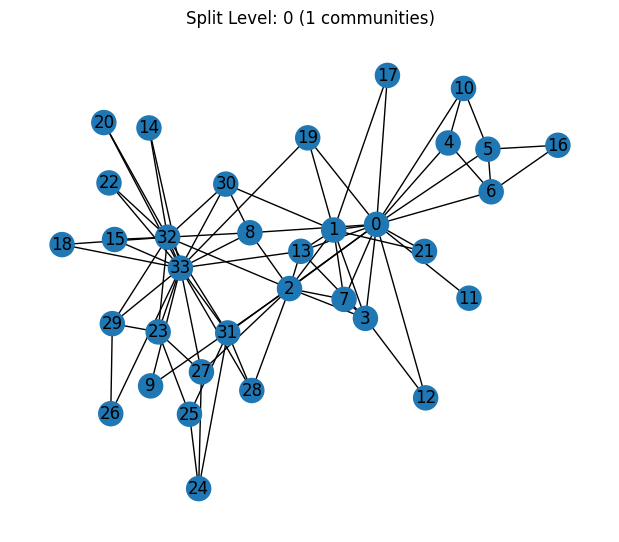

Iteration 1: 2 communities


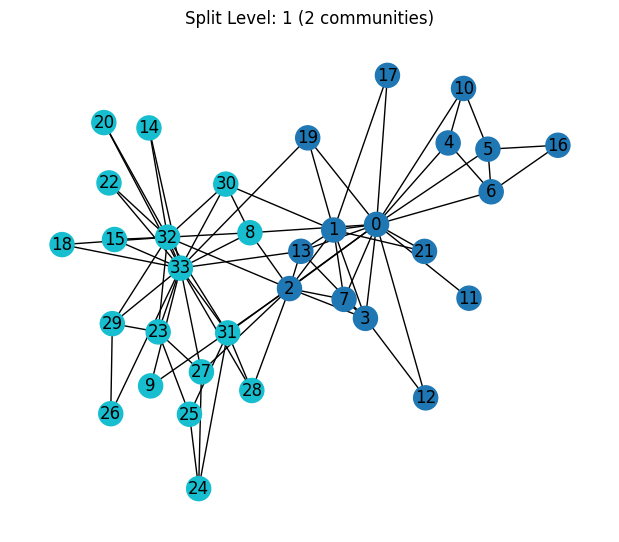

Iteration 2: 3 communities


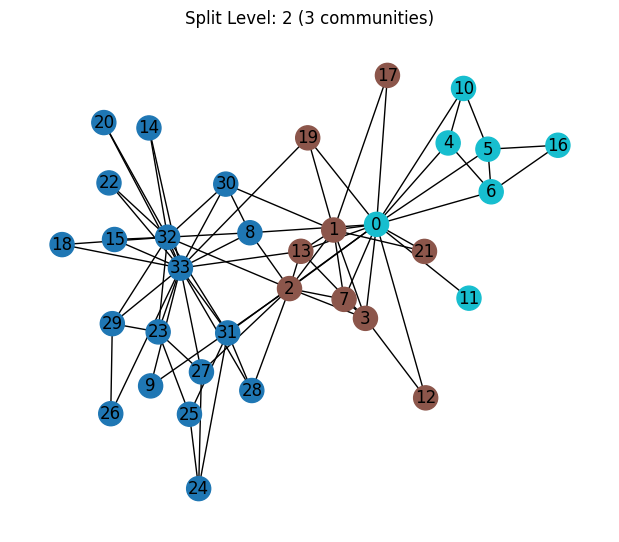

Iteration 3: 4 communities


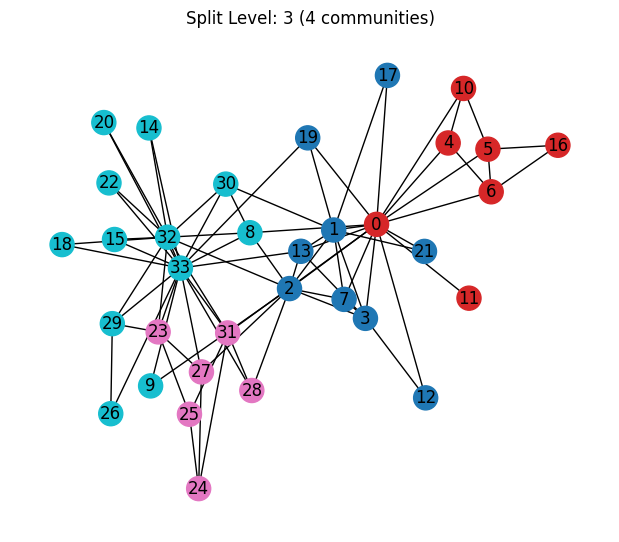


Identified 4 clusters

0.4210940574576938
Communities:
  Community 0: {1, 2, 3, 7, 12, 13, 17, 19, 21}
  Community 1: {0, 4, 5, 6, 10, 11, 16}
  Community 2: {23, 24, 25, 27, 28, 31}
  Community 3: {32, 33, 8, 9, 14, 15, 18, 20, 22, 26, 29, 30}


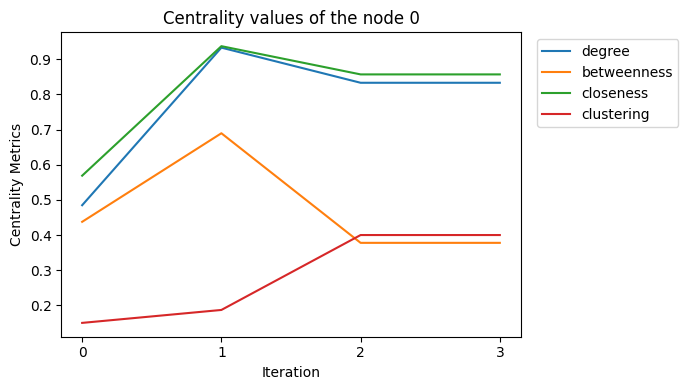

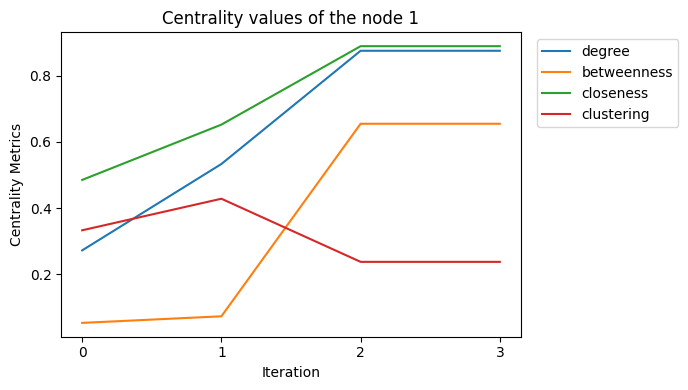

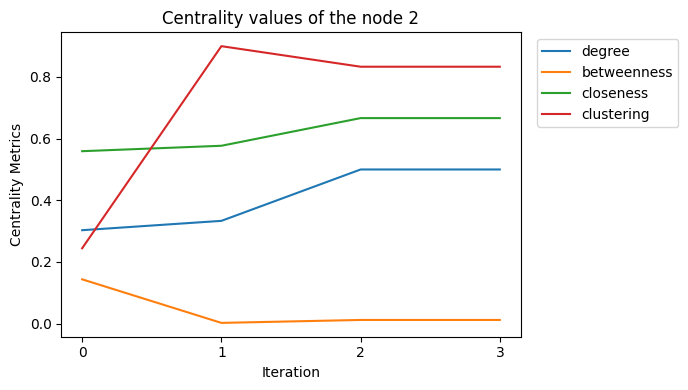

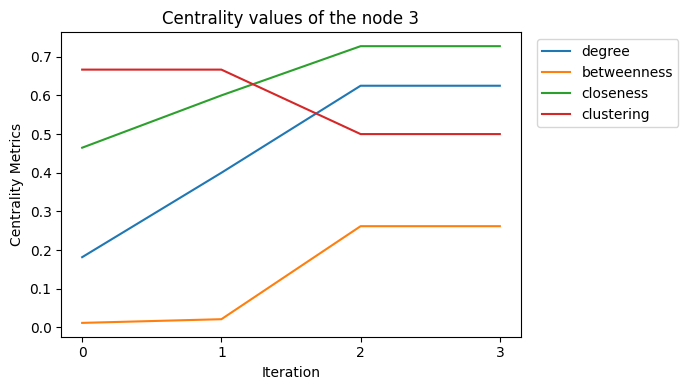

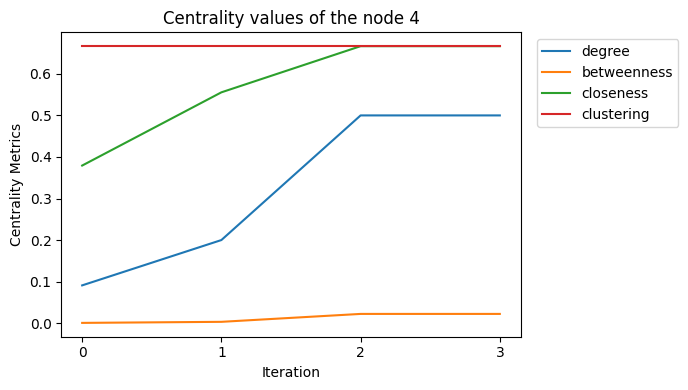

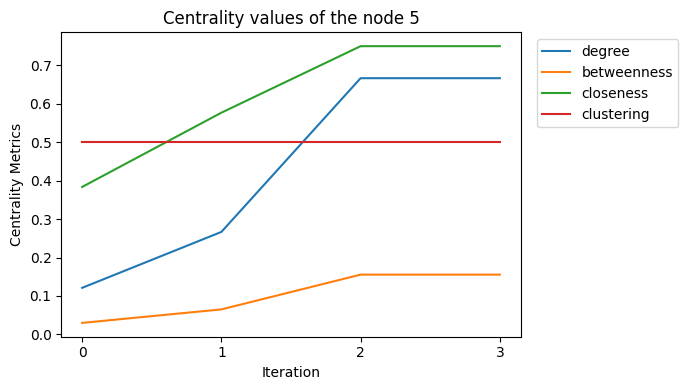

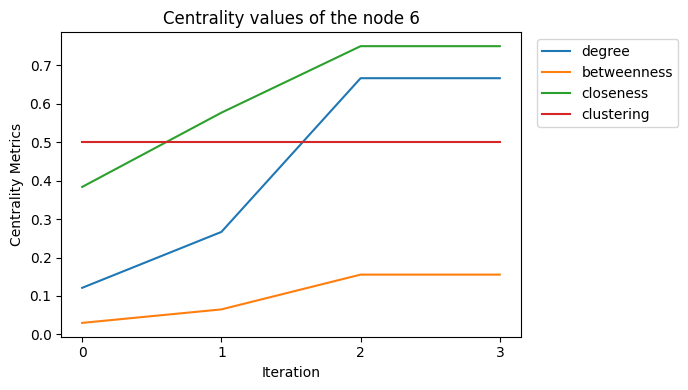

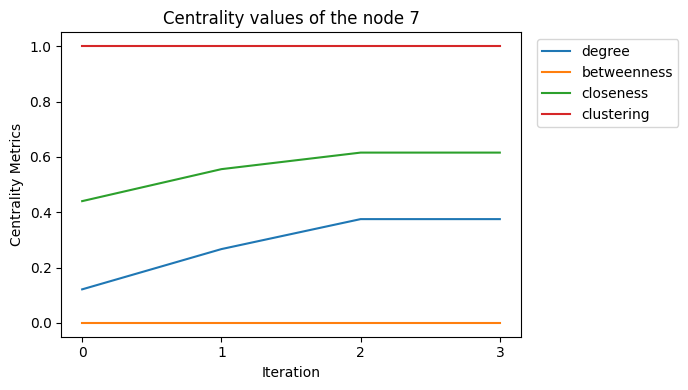

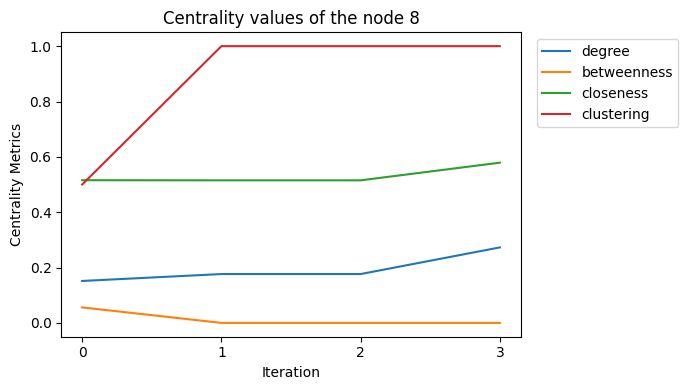

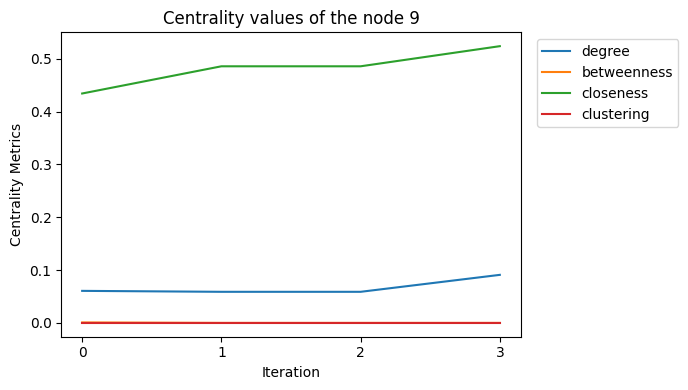

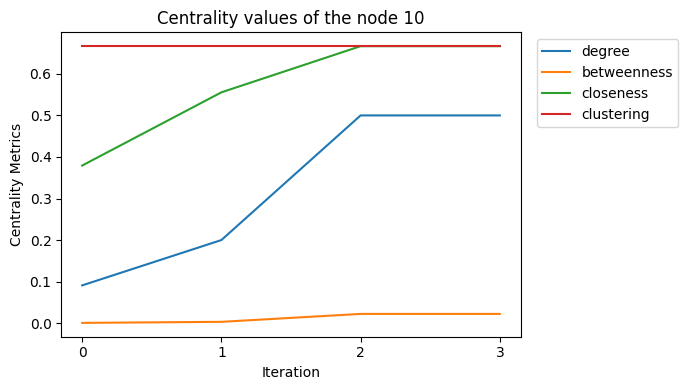

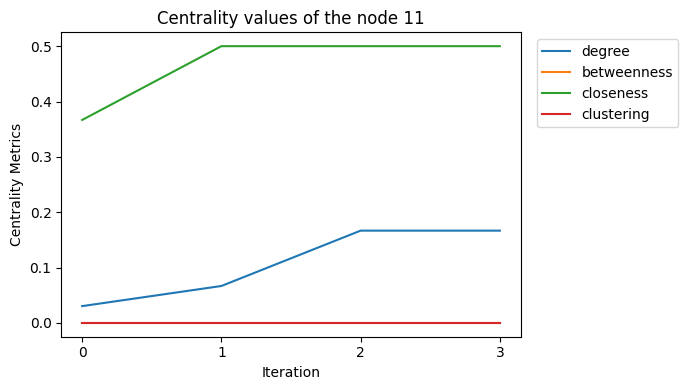

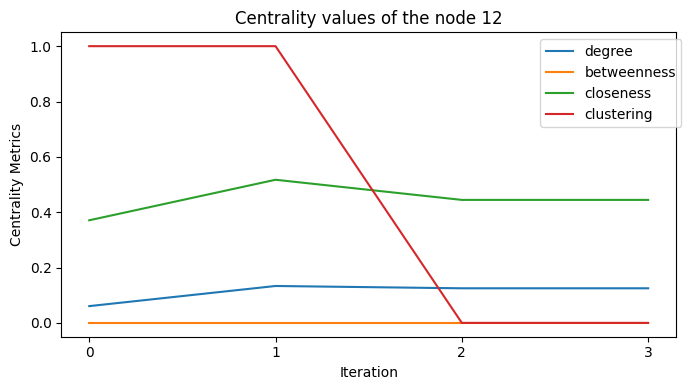

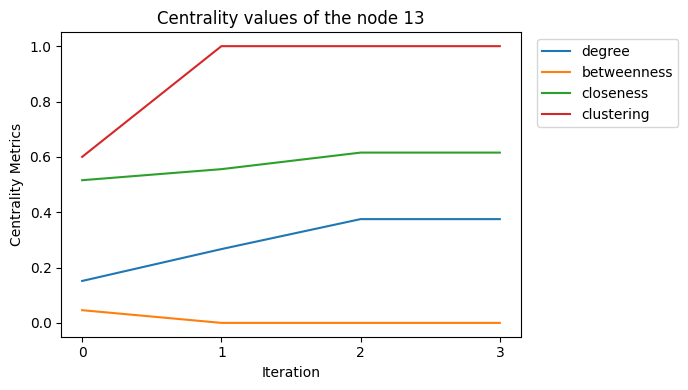

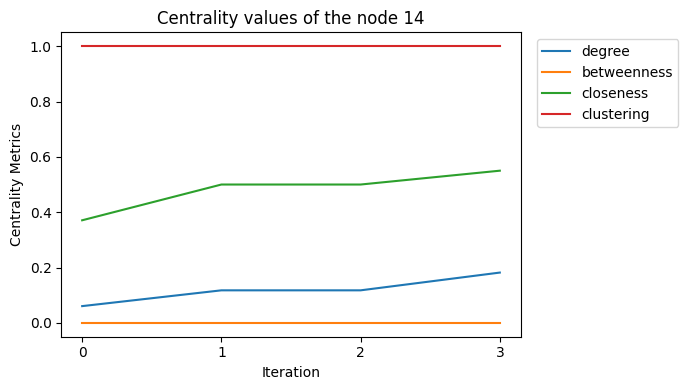

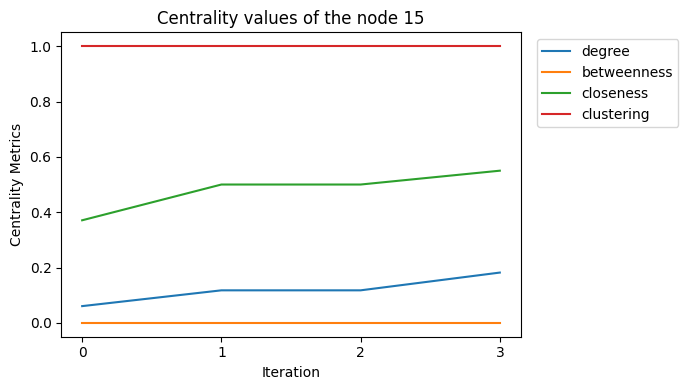

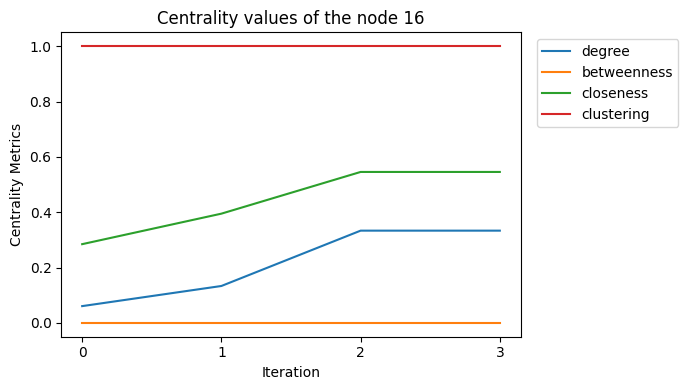

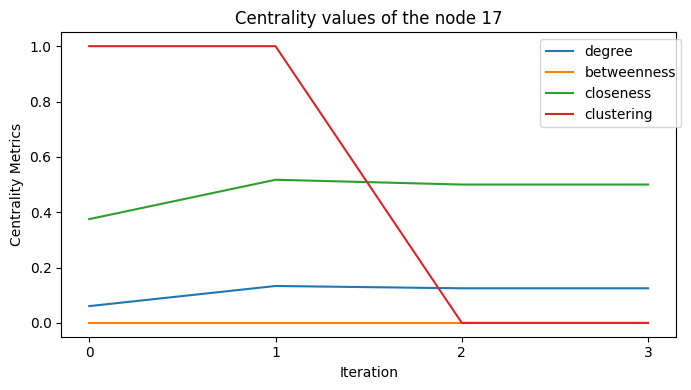

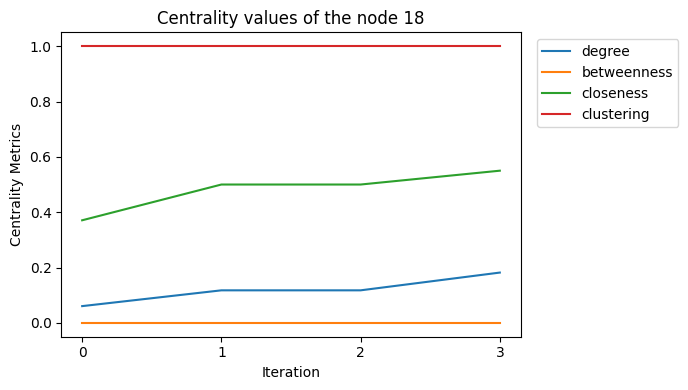

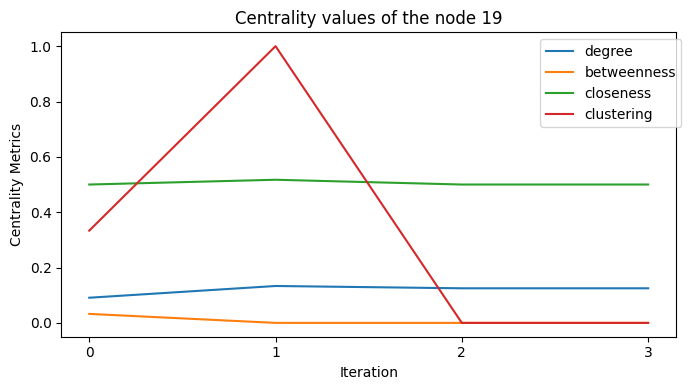

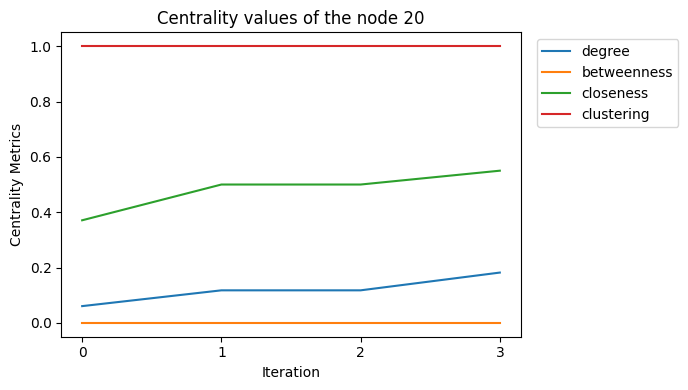

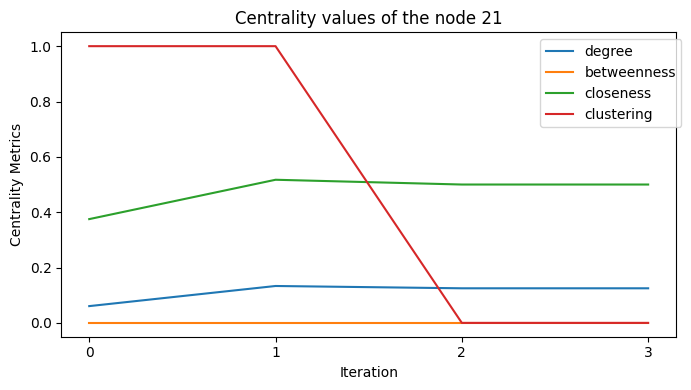

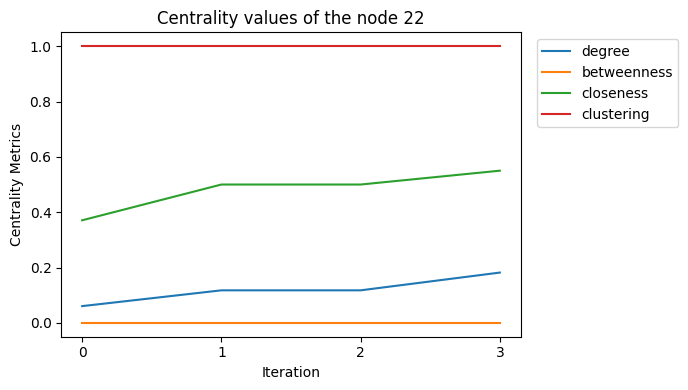

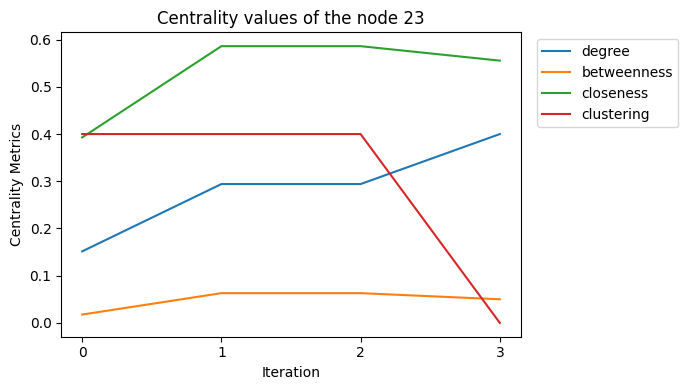

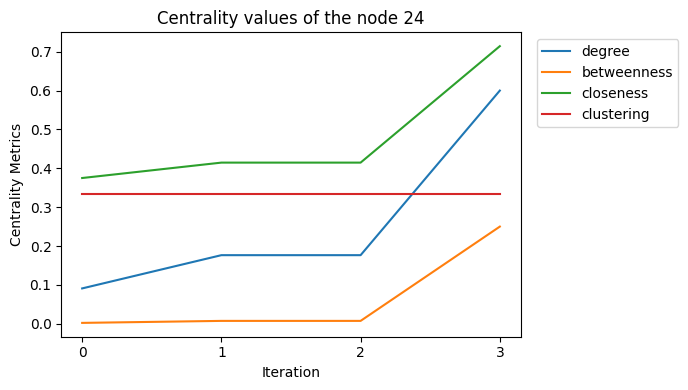

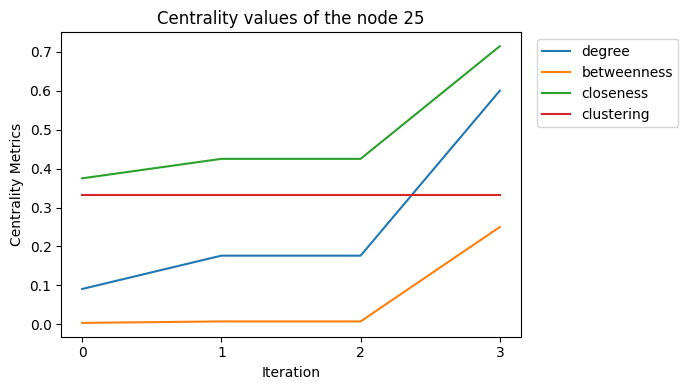

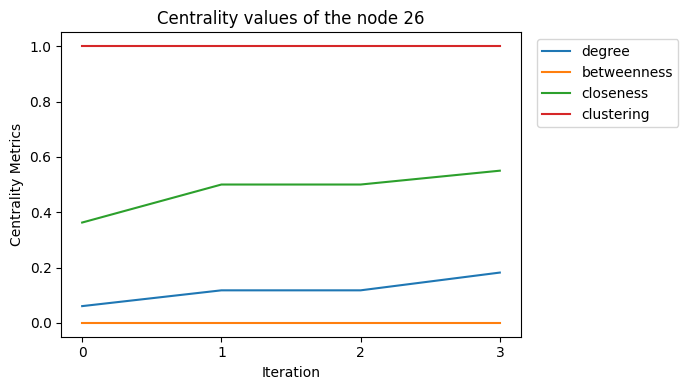

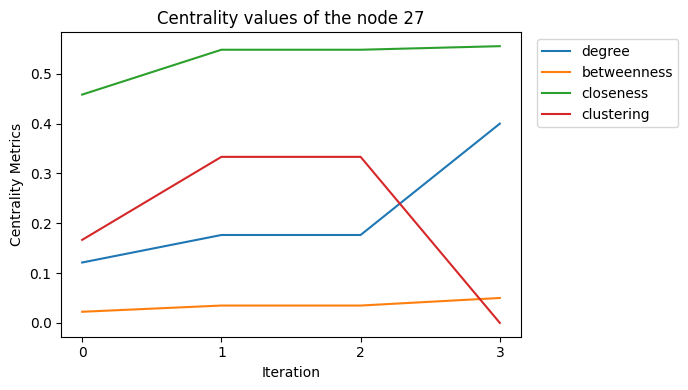

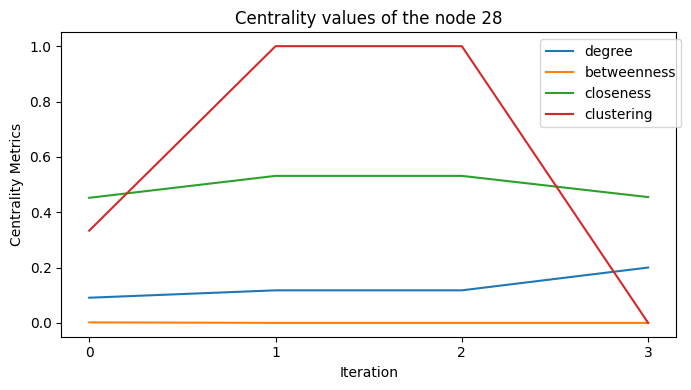

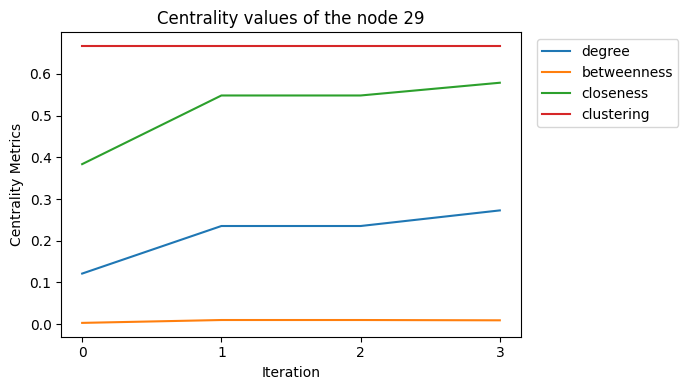

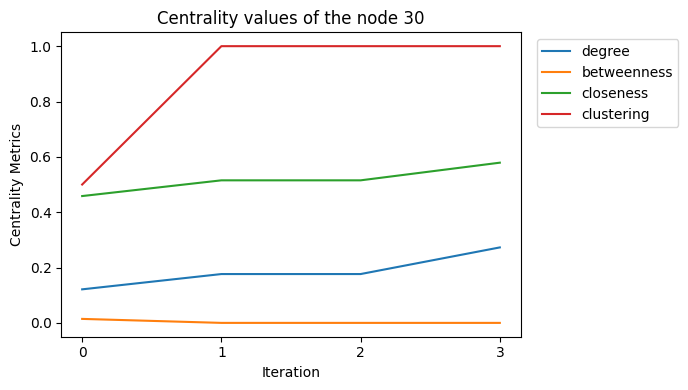

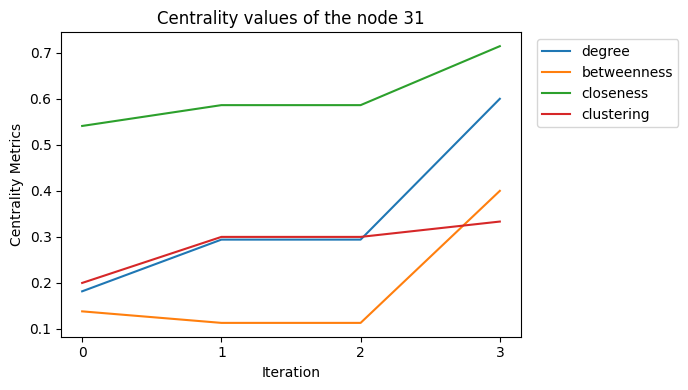

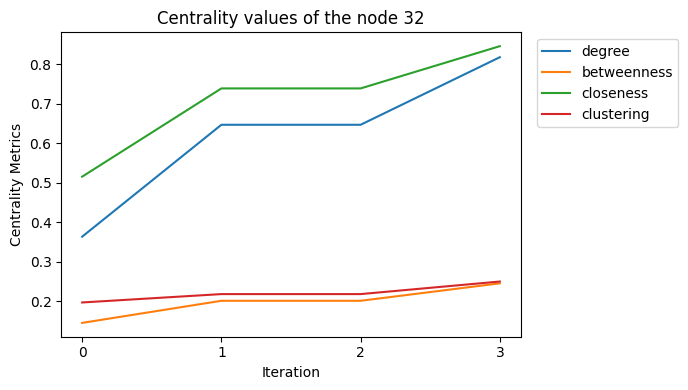

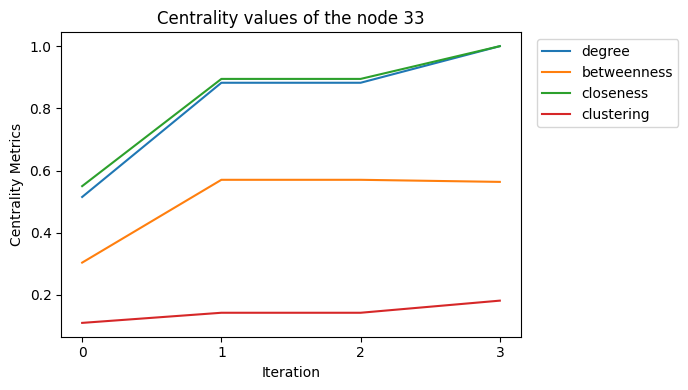

In [55]:
if __name__ == "__main__":
    main(show_plots=True, max_clusters=None)